# Práctica 2 — Análisis Exploratorio de Datos con Python

# Importación de librerías

In [7]:
# =========================================================
# IMPORTACIÓN DE LIBRERÍAS
# =========================================================

# NumPy se usa para operaciones matemáticas y arreglos
import numpy as np

# Pandas se usa para manejo y análisis de datos
import pandas as pd

# Matplotlib se usa para crear gráficas
import matplotlib.pyplot as plt

# Seaborn se usa para gráficas estadísticas más avanzadas
import seaborn as sns

# Carga del dataset

In [8]:
# =========================================================
# CARGA DEL DATASET
# =========================================================

# Cargamos el archivo CSV dentro de un DataFrame
stars = pd.read_csv("star_dataset.csv")

# Mostrar primeras filas

In [9]:
# =========================================================
# MOSTRAR LAS PRIMERAS FILAS
# =========================================================

# Mostramos las primeras 5 filas del dataset
stars.head()

,Name,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K),Spectral Class
0,Altair,16.594171,9.979192,1.632650,7509.294247,A7V
1,Deneb,2600.490723,196002.627856,202.970526,8503.284796,A2Ia
2,Barnard's Star,6.052616,4.893716,0.222711,3165.959639,M4Ve
3,Polaris,322.601002,2196.241934,37.546813,6048.326915,F7Ib
4,Barnard's Star,5.902392,-1.496486,0.192359,3130.602069,M4Ve


# Dimensiones del dataset

In [10]:
# =========================================================
# DIMENSIONES DEL DATASET
# =========================================================

print("Dimensiones del dataset:")
print(stars.shape)

Dimensiones del dataset:
(1000, 6)


# Tipos de datos

In [11]:
# =========================================================
# TIPOS DE DATOS
# =========================================================

print("Tipos de datos del dataset:")
print(stars.dtypes)

Tipos de datos del dataset:
Name                  object
Distance (ly)        float64
Luminosity (L/Lo)    float64
Radius (R/Ro)        float64
Temperature (K)      float64
Spectral Class        object
dtype: object


# Estadísticas descriptivas

In [12]:
# =========================================================
# ESTADÍSTICAS DESCRIPTIVAS
# =========================================================

print("Estadísticas descriptivas:")
stars.describe()

Estadísticas descriptivas:


,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,295.505327,19644.909442,86.960696,9983.486779
std,541.478403,42223.595017,213.850005,7906.973529
min,3.877798,-4.993141,0.068087,2750.183163
25%,11.716853,10.441039,1.664479,3940.020856
50%,52.031435,171.097809,5.845444,7379.007975
75%,322.865874,10500.577117,33.719778,12055.975095
max,2600.490723,196004.854081,887.097936,28044.279272


# Valores nulos

In [13]:
# =========================================================
# VERIFICAR VALORES NULOS
# =========================================================

print("Valores nulos por columna:")
print(stars.isnull().sum())

Valores nulos por columna:
Name                 0
Distance (ly)        0
Luminosity (L/Lo)    0
Radius (R/Ro)        0
Temperature (K)      0
Spectral Class       0
dtype: int64


# Conteo por clase espectral

In [14]:
# =========================================================
# CONTAR ESTRELLAS POR CLASE ESPECTRAL
# =========================================================

print("Cantidad de estrellas por clase espectral:")
print(stars["Spectral Class"].value_counts())

Cantidad de estrellas por clase espectral:
Spectral Class
A7V         74
A1V         73
A9II        48
B1III       45
M3.5V       45
M2Iab       44
G8III       39
M4Ve        38
K1.5III     38
A0V         38
M7IIIe      37
B2III       37
B0Ia        36
G2V         36
F7Ib        35
B1III-IV    32
A3V         31
F5IV-V      30
B0.5IV      30
B6Vep       29
M2.1V       27
B7V         26
M1.5Iab     26
A2Ia        25
K1V         24
M6V         22
K5III       18
B8Ia        17
Name: count, dtype: int64


# Promedio A7V usando for

In [15]:
# =========================================================
# TEMPERATURA MEDIA DE A7V USANDO CICLO FOR
# =========================================================

stars_a7v = stars[stars["Spectral Class"] == "A7V"]

suma_temperaturas = 0
contador = 0

for temperatura in stars_a7v["Temperature (K)"]:
    suma_temperaturas += temperatura
    contador += 1

promedio_a7v = suma_temperaturas / contador

print("Temperatura promedio de estrellas A7V:")
print(promedio_a7v)

Temperatura promedio de estrellas A7V:
7550.178312906775


# Groupby

In [16]:
# =========================================================
# TEMPERATURA PROMEDIO POR CLASE USANDO GROUPBY
# =========================================================

promedios_por_clase = stars.groupby("Spectral Class")["Temperature (K)"].mean()

print("Promedio de temperatura por clase espectral:")
print(promedios_por_clase)

print("\nComparación con el cálculo manual de A7V:")
print("Promedio manual A7V:", promedio_a7v)
print("Promedio con groupby A7V:")
print(promedios_por_clase["A7V"])

Promedio de temperatura por clase espectral:
Spectral Class
A0V          9607.458129
A1V         10136.022204
A2Ia         8516.840653
A3V          8584.693288
A7V          7550.178313
A9II         7349.223744
B0.5IV      28001.166630
B0Ia        27502.303666
B1III       25001.131122
B1III-IV    25403.170510
B2III       22600.139741
B6Vep       15003.610593
B7V         12462.119029
B8Ia        12092.293145
F5IV-V       6520.419327
F7Ib         6020.393400
G2V          5797.996506
G8III        4939.733287
K1.5III      4280.090548
K1V          5261.645715
K5III        3923.614977
M1.5Iab      3499.130207
M2.1V        3408.914115
M2Iab        3502.196868
M3.5V        2802.627176
M4Ve         3136.076002
M6V          2795.196060
M7IIIe       2914.515688
Name: Temperature (K), dtype: float64

Comparación con el cálculo manual de A7V:
Promedio manual A7V: 7550.178312906775
Promedio con groupby A7V:
7550.178312906777


# Estadísticas NumPy

In [17]:
# =========================================================
# ESTADÍSTICAS CON NUMPY
# =========================================================

temperaturas = stars["Temperature (K)"].values

media_temp = np.mean(temperaturas)
mediana_temp = np.median(temperaturas)
std_temp = np.std(temperaturas)

print("Media de temperaturas:", media_temp)
print("Mediana de temperaturas:", mediana_temp)
print("Desviación estándar:", std_temp)

Media de temperaturas: 9983.486778663919
Mediana de temperaturas: 7379.00797517653
Desviación estándar: 7903.019053162096


# Percentiles

In [18]:
# =========================================================
# PERCENTILES DEL RADIO ESTELAR
# =========================================================

radios = stars["Radius (R/Ro)"].values

percentiles = np.percentile(radios, [25, 50, 75, 90])

print("Percentil 25:", percentiles[0])
print("Percentil 50:", percentiles[1])
print("Percentil 75:", percentiles[2])
print("Percentil 90:", percentiles[3])

Percentil 25: 1.664479197594917
Percentil 50: 5.845443555115757
Percentil 75: 33.71977798607205
Percentil 90: 369.92670005634596


# Gráfica de barras

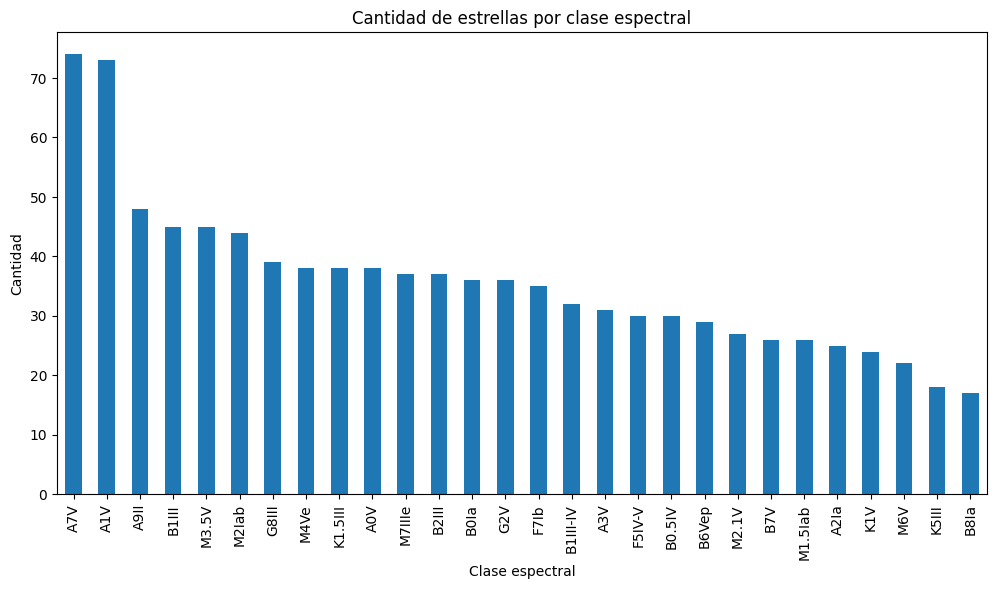

In [19]:
# =========================================================
# GRÁFICA DE BARRAS
# =========================================================

conteo_clases = stars["Spectral Class"].value_counts()

plt.figure(figsize=(12, 6))

conteo_clases.plot(kind="bar")

plt.title("Cantidad de estrellas por clase espectral")
plt.xlabel("Clase espectral")
plt.ylabel("Cantidad")

plt.show()

# Boxplot

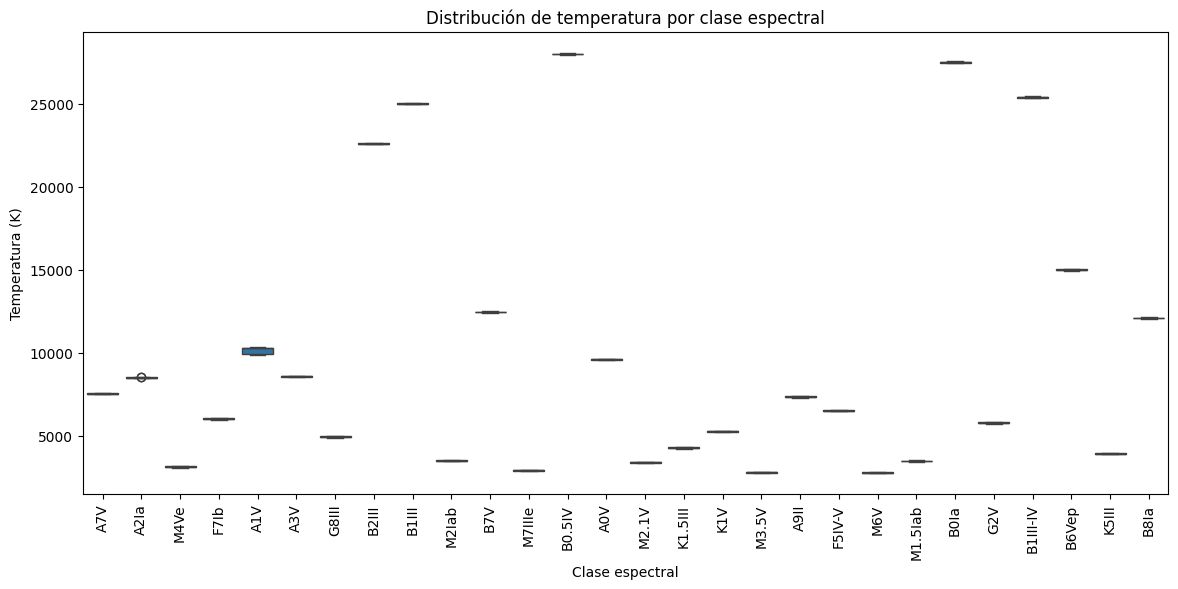

In [20]:
# =========================================================
# BOXPLOT
# =========================================================

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=stars,
    x="Spectral Class",
    y="Temperature (K)"
)

plt.xticks(rotation=90)

plt.title("Distribución de temperatura por clase espectral")
plt.xlabel("Clase espectral")
plt.ylabel("Temperatura (K)")

plt.show()

# Scatter plot

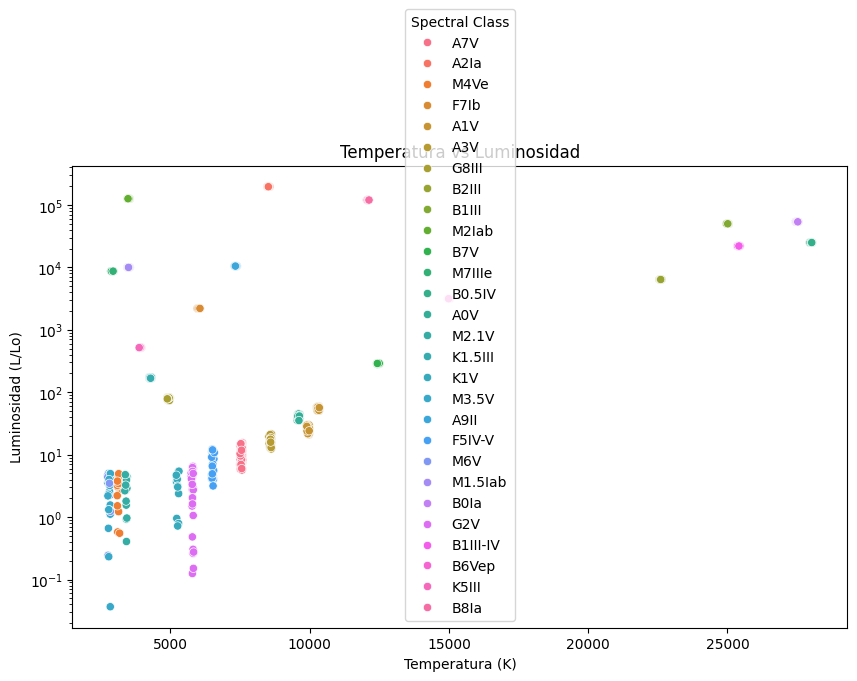

In [21]:
# =========================================================
# SCATTER PLOT
# =========================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=stars,
    x="Temperature (K)",
    y="Luminosity (L/Lo)",
    hue="Spectral Class"
)

plt.yscale("log")

plt.title("Temperatura vs Luminosidad")
plt.xlabel("Temperatura (K)")
plt.ylabel("Luminosidad (L/Lo)")

plt.show()

# Diagrama Hertzsprung-Russell

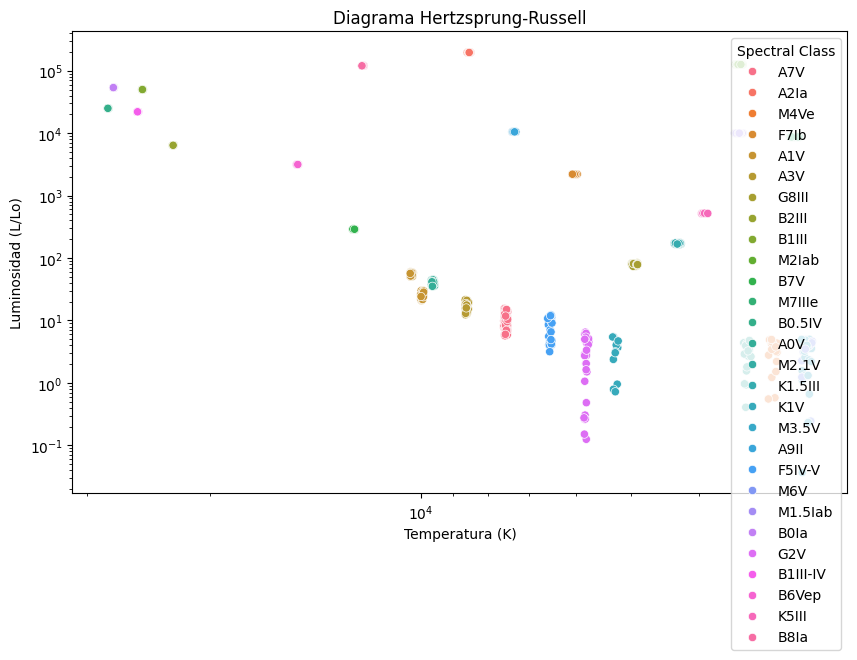

In [22]:
# =========================================================
# DIAGRAMA HERTZSPRUNG-RUSSELL
# =========================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=stars,
    x="Temperature (K)",
    y="Luminosity (L/Lo)",
    hue="Spectral Class"
)

plt.xscale("log")
plt.yscale("log")

plt.gca().invert_xaxis()

plt.title("Diagrama Hertzsprung-Russell")
plt.xlabel("Temperatura (K)")
plt.ylabel("Luminosidad (L/Lo)")

plt.show()

# Array NumPy

In [23]:
# =========================================================
# EXTRAER ARRAY NUMPY
# =========================================================

temperaturas = stars["Temperature (K)"].values

print(type(temperaturas))

<class 'numpy.ndarray'>


# Estadísticas finales

In [24]:
# =========================================================
# MEDIA, MEDIANA Y DESVIACIÓN ESTÁNDAR
# =========================================================

media = np.mean(temperaturas)
mediana = np.median(temperaturas)
std = np.std(temperaturas)

print("Media:", media)
print("Mediana:", mediana)
print("Desviación estándar:", std)

Media: 9983.486778663919
Mediana: 7379.00797517653
Desviación estándar: 7903.019053162096


# Percentiles finales

In [25]:
# =========================================================
# PERCENTILES DEL RADIO ESTELAR
# =========================================================

radios = stars["Radius (R/Ro)"].values

p25 = np.percentile(radios, 25)
p50 = np.percentile(radios, 50)
p75 = np.percentile(radios, 75)
p90 = np.percentile(radios, 90)

print("Percentil 25:", p25)
print("Percentil 50:", p50)
print("Percentil 75:", p75)
print("Percentil 90:", p90)

Percentil 25: 1.664479197594917
Percentil 50: 5.845443555115757
Percentil 75: 33.71977798607205
Percentil 90: 369.92670005634596


# Kelvin a Celsius

In [26]:
# =========================================================
# CONVERSIÓN DE KELVIN A CELSIUS
# =========================================================

celsius = temperaturas - 273.15

print("Primeras temperaturas en Celsius:")
print(celsius[:10])

Primeras temperaturas en Celsius:
[ 7236.14424736  8230.13479643  2892.80963924  5775.17691476
  2857.45206924  9630.82170375  8268.04535514  4706.34246209
  4634.62954887 22300.1361772 ]
